# PART 1 — Dataset Understanding

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv('heart.csv')


In [39]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title='Heart Analysis')
profile.to_file('my_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 432.04it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
df.shape

(1025, 14)

# Total Feature & Sample

In [41]:
print(f"Total Feature: {df.shape[1]}")
print(f"Total Samples: {df.shape[0]}")

Total Feature: 14
Total Samples: 1025


In [42]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [43]:
df.sample(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
934,42,1,2,130,180,0,1,150,0,0.0,2,0,2,1
79,52,1,1,134,201,0,1,158,0,0.8,2,1,2,1
961,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
353,57,1,0,110,201,0,1,126,1,1.5,1,0,1,1
339,60,1,0,130,253,0,1,144,1,1.4,2,1,3,0
866,41,1,2,112,250,0,1,179,0,0.0,2,0,2,1
891,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
833,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
402,70,1,1,156,245,0,0,143,0,0.0,2,0,2,1
478,39,1,2,140,321,0,0,182,0,0.0,2,0,2,1


In [44]:
cat_cols = df.select_dtypes(include=['object']).columns

num_cols = df.select_dtypes(exclude='object').columns

print(f'Categorical Columns: {cat_cols}')
print(f'Numerical Columns: {num_cols}')

Categorical Columns: Index([], dtype='object')
Numerical Columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


# PART 2 — Feature Screening & Cleaning

In [45]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<Axes: >

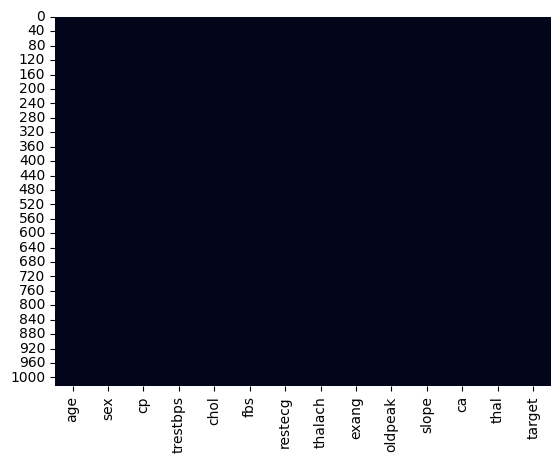

In [46]:
sns.heatmap(df.isnull(), cbar=False)

In [47]:
df.duplicated().sum()

np.int64(723)

In [48]:
df.drop_duplicates(inplace=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [50]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# PART 3 — Univariate Analysis

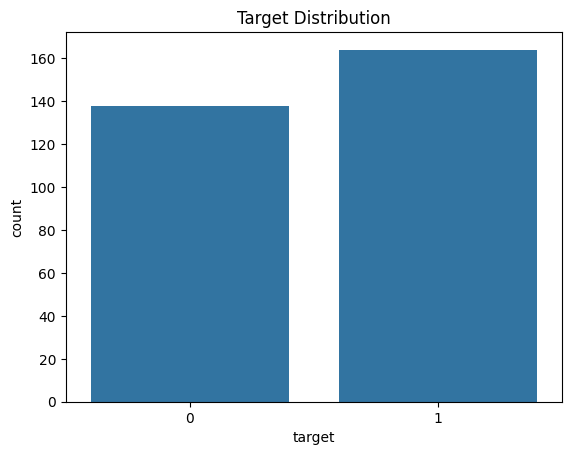

In [51]:
sns.countplot(data=df, x='target')
plt.title('Target Distribution')
plt.show()

In [52]:
target_ana = pd.DataFrame({'Count' : df['target'].value_counts(), 
                          'Percentage': df['target'].value_counts(normalize=True)})

target_ana

,Count,Percentage
target,,
1,164,0.543046
0,138,0.456954


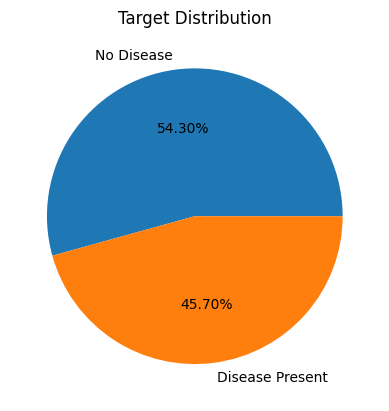

In [53]:
target_count = df['target'].value_counts()

target_labels = ['No Disease', 'Disease Present']

plt.pie(target_count, labels=target_labels, autopct='%1.2f%%')
plt.title('Target Distribution')

plt.show()

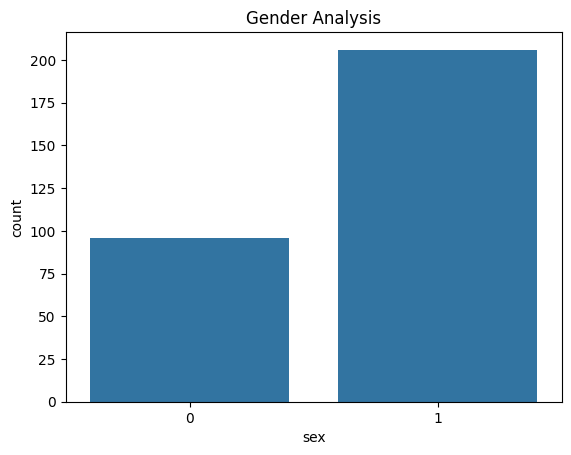

In [54]:
sns.countplot(data=df, x='sex')
plt.title('Gender Analysis')
plt.show()

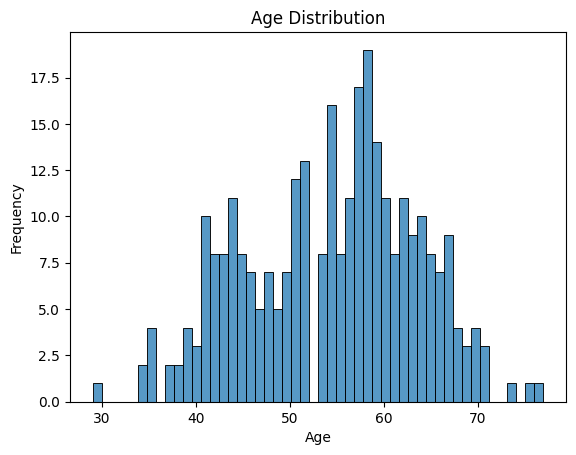

In [55]:
# age distribution

sns.histplot(data=df, x='age', bins=50)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

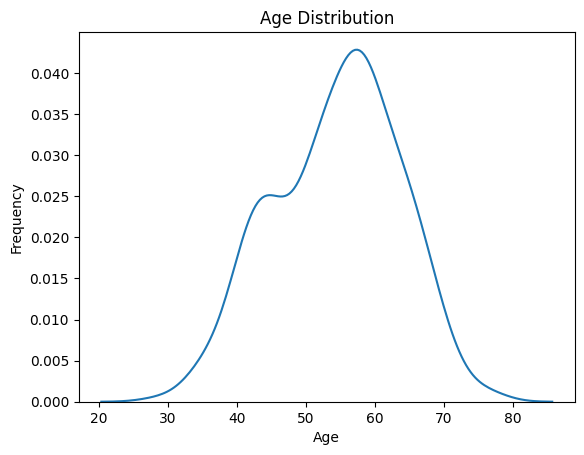

In [56]:
sns.kdeplot(data=df, x='age')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

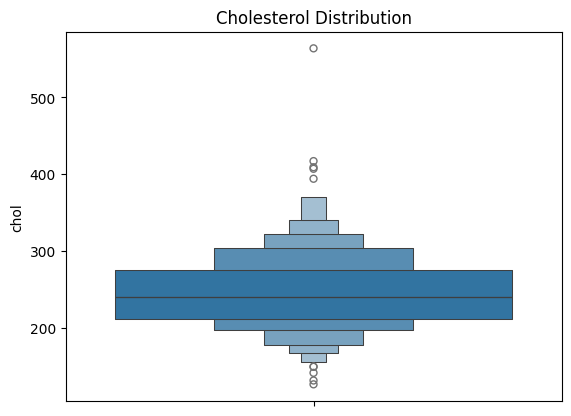

In [57]:
sns.boxenplot(df['chol'])
plt.title('Cholesterol Distribution')
plt.show()

## Step 15 — Outlier Detection using IQR

In [58]:
Q1 = df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['chol'] < lower_bound) | (df['chol'] > upper_bound)]
print(outliers)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
123   65    0   2       140   417    1        0      157      0      0.8   
158   67    0   2       115   564    0        0      160      0      1.6   
179   56    0   0       134   409    0        0      150      1      1.9   
255   62    0   0       140   394    0        0      157      0      1.2   
450   63    0   0       150   407    0        0      154      0      4.0   

     slope  ca  thal  target  
123      2   1     2       1  
158      1   0     3       1  
179      1   2     3       0  
255      1   0     2       1  
450      1   3     3       0  


In [59]:
df['age'].skew()

np.float64(-0.20374327959596905)

# Part 4 - Multivariate Analysis

### Step 17 — Gender vs Heart Disease-Countpolt

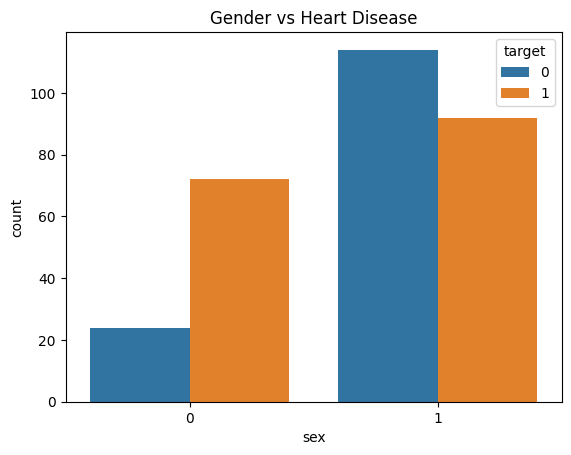

In [60]:
sns.countplot(data=df, x='sex', hue='target')

plt.title('Gender vs Heart Disease')
plt.show()

In [61]:
# Groupby Analysis

gender_split= df.groupby('sex')['target'].value_counts(normalize=True)

print(gender_split)

sex  target
0    1         0.750000
     0         0.250000
1    0         0.553398
     1         0.446602
Name: proportion, dtype: float64


### Step 18 - Countplot- Chest Pain vs Heart Disease

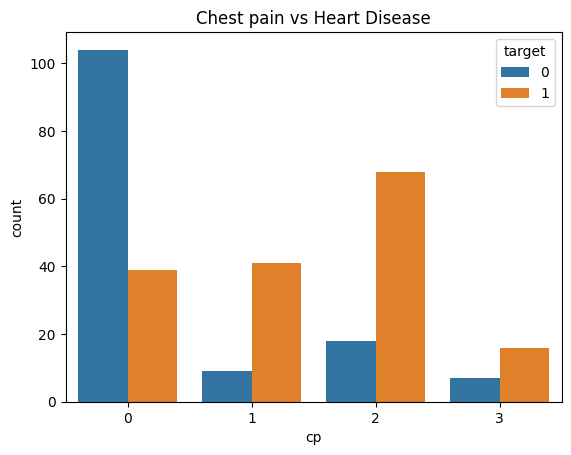

In [62]:
sns.countplot(data = df, x = 'cp', hue='target')

plt.title('Chest pain vs Heart Disease')
plt.show()

### Step 21 — Barplot Analysis

<Axes: xlabel='target', ylabel='chol'>

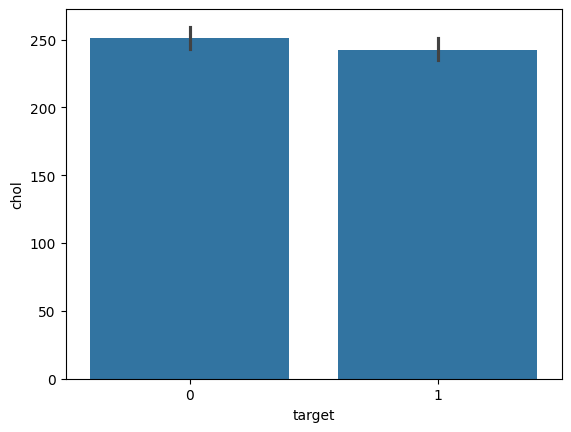

In [63]:
sns.barplot(data = df, x = 'target', y = 'chol')

<Axes: xlabel='age', ylabel='chol'>

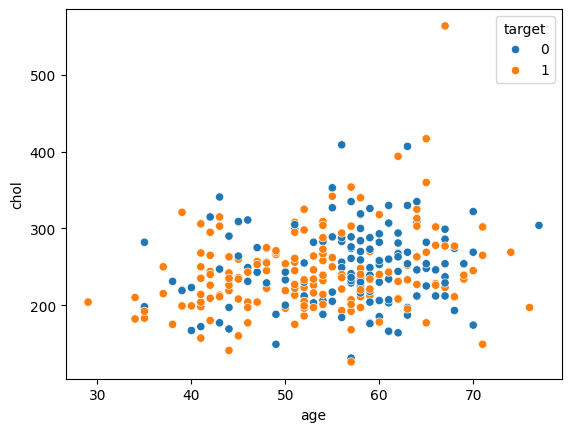

In [64]:
sns.scatterplot(data=df, x='age', y='chol', hue='target')

### Step 24 — Pairplot Analysis

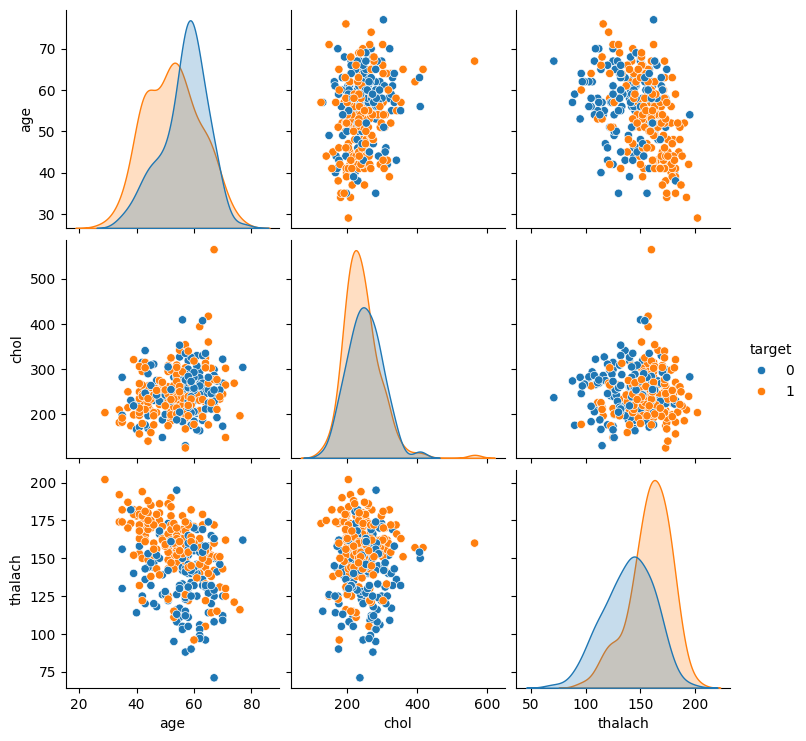

In [65]:
sns.pairplot(df[['age', 'chol', 'thalach', 'target']], hue='target')

### Step 25 — Correlation Heatmap

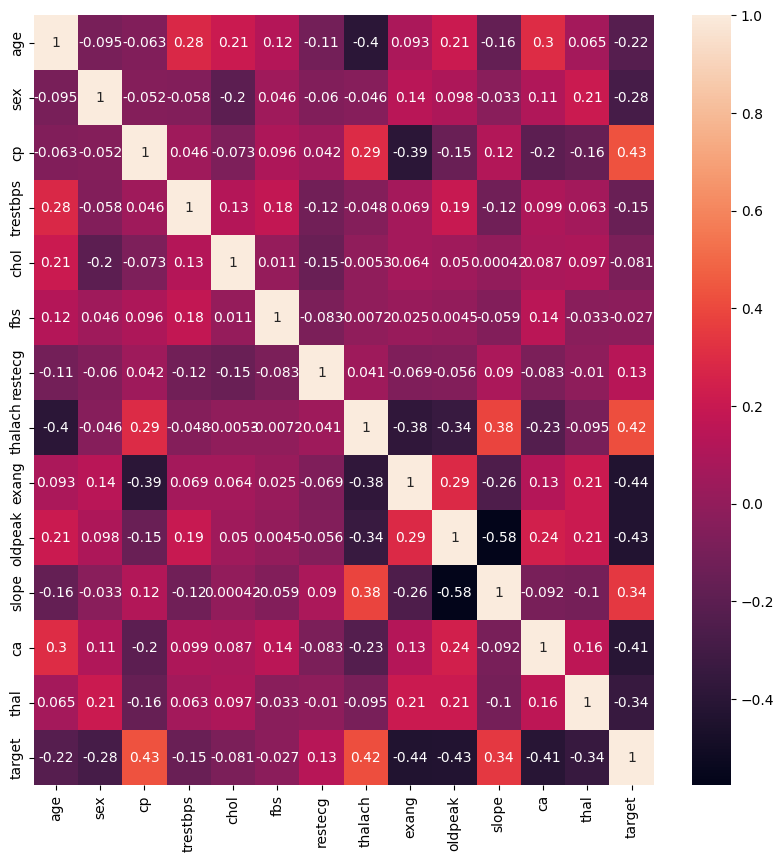

In [66]:
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(), annot=True)

plt.show()